# Análisis Exploratorio del Dataset Enriquecido

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
sns.set(style="whitegrid")

df = pd.read_csv(r"C:\Users\GOLDEN\Desktop\meli-case-tecnico\airflow\data\output\final_dataset.csv")
df.head()

,timestamp,user_id,value_prop_id,was_clicked,views_last_3_weeks,clicks_count,payments_last_3_weeks,total_amount_last_3_weeks
0,2020-11-23,69000,credits_consumer,False,0.0,0.0,0.0,0.00
1,2020-11-23,69000,link_cobro,False,0.0,0.0,0.0,0.00
2,2020-11-23,69000,transport,False,1.0,0.0,1.0,136.73
3,2020-11-23,69000,prepaid,False,0.0,0.0,3.0,143.82
4,2020-11-23,66521,prepaid,False,0.0,0.0,1.0,157.87


In [5]:
# Información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127554 entries, 0 to 127553
Data columns (total 8 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   timestamp                  127554 non-null  object 
 1   user_id                    127554 non-null  int64  
 2   value_prop_id              127554 non-null  object 
 3   was_clicked                127554 non-null  bool   
 4   views_last_3_weeks         127554 non-null  float64
 5   clicks_count               127554 non-null  float64
 6   payments_last_3_weeks      127554 non-null  float64
 7   total_amount_last_3_weeks  127554 non-null  float64
dtypes: bool(1), float64(4), int64(1), object(2)
memory usage: 6.9+ MB


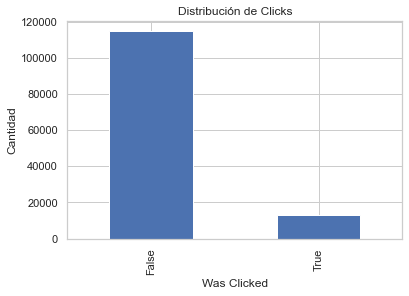

In [6]:
# Distribución de clics
df['was_clicked'].value_counts().plot(kind='bar', title='Distribución de Clicks')
plt.xlabel('Was Clicked')
plt.ylabel('Cantidad')
plt.show()

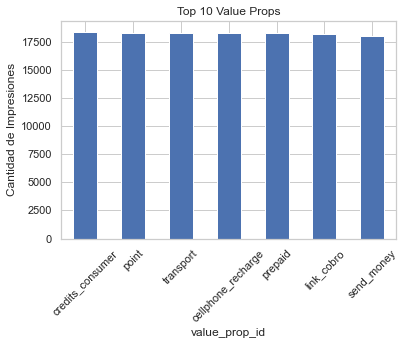

In [7]:
# Top value props
top_props = df['value_prop_id'].value_counts().head(10)
top_props.plot(kind='bar', title='Top 10 Value Props')
plt.ylabel('Cantidad de Impresiones')
plt.xticks(rotation=45)
plt.show()

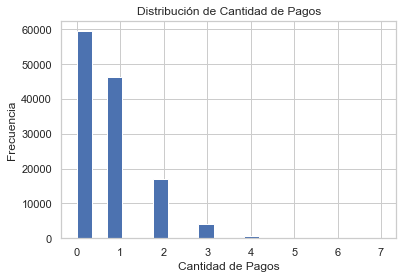

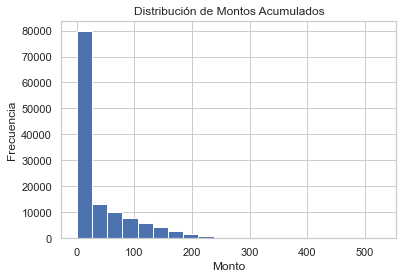

In [8]:
# Distribución de pagos
df['payments_last_3_weeks'].hist(bins=20)
plt.title('Distribución de Cantidad de Pagos')
plt.xlabel('Cantidad de Pagos')
plt.ylabel('Frecuencia')
plt.show()

df['total_amount_last_3_weeks'].hist(bins=20)
plt.title('Distribución de Montos Acumulados')
plt.xlabel('Monto')
plt.ylabel('Frecuencia')
plt.show()

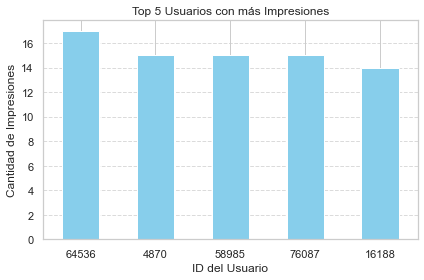

In [10]:
# Top 5 usuarios con más impresiones
top_users = df['user_id'].value_counts().head(5)
top_users.plot(kind='bar', title='Top 5 Usuarios con más Impresiones', color='skyblue')
plt.ylabel('Cantidad de Impresiones')
plt.xlabel('ID del Usuario')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

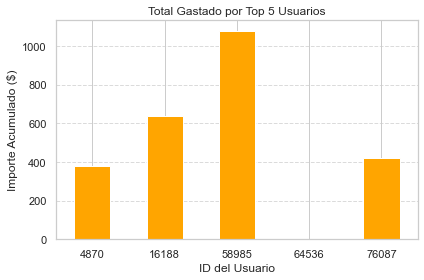

In [11]:
# Total gastado por los Top 5 usuarios
top_user_ids = top_users.index.tolist()
user_spending = df[df['user_id'].isin(top_user_ids)].groupby('user_id')['total_amount_last_3_weeks'].sum()

user_spending.plot(kind='bar', title='Total Gastado por Top 5 Usuarios', color='orange')
plt.ylabel('Importe Acumulado ($)')
plt.xlabel('ID del Usuario')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()